In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, SelectFromModel, VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [2]:
plt.style.use("ggplot")

## **Data Cleaning**

In [3]:
file_path = os.path.join(
    kagglehub.dataset_download("ka66ledata/project-management-risk-raw"),
    "project_risk_raw_dataset.csv"
)

Using Colab cache for faster access to the 'project-management-risk-raw' dataset.


In [4]:
df = pd.read_csv(file_path, index_col=0)
df.head()

,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,External_Dependencies_Count,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
Project_ID,,,,,,,,,,,,,,,,,,,,,
PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,2,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,0,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,5,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,2,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


In [5]:
# duplicated
print("duplicados:", df.duplicated().sum())

# missing
missing = pd.concat([df.isnull().sum(), (df.isnull().mean()*100)], axis=1)
missing.columns = ["missing_count", "missing_%"]
display(missing.sort_values("missing_count", ascending=False).head(30))

duplicados: 0


,missing_count,missing_%
Tech_Environment_Stability,2619,65.475
Risk_Management_Maturity,791,19.775
Change_Control_Maturity,780,19.500
Project_Budget_USD,0,0.000
Complexity_Score,0,0.000
Stakeholder_Count,0,0.000
Methodology_Used,0,0.000
Estimated_Timeline_Months,0,0.000
Past_Similar_Projects,0,0.000
External_Dependencies_Count,0,0.000


In [6]:
# target
display(
    pd.concat([
        df["Risk_Level"].value_counts(dropna=False),
        df["Risk_Level"].value_counts(normalize=True, dropna=False).round(2)
    ], axis=1)
)

df["Risk_Level"] = df["Risk_Level"].replace({
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Critical": 3
}).astype("int")

,count,proportion
Risk_Level,,
Medium,1396,0.35
High,1036,0.26
Low,806,0.20
Critical,762,0.19


/tmp/ipython-input-1992704477.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Risk_Level"] = df["Risk_Level"].replace({


In [7]:
# eliminar columnas con más de 50% de datos faltantes
thresh_pct = 50
cols_drop = missing[missing["missing_%"] > thresh_pct].index.tolist()
print("columns to DROP (>50% missing):", cols_drop)
df = df.drop(columns=cols_drop)

# agrupar categorías raras (frecuencia < 1%)
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols: num_cols.remove("Risk_Level")

for c in cat_cols:
    freq = df[c].value_counts(normalize=True)
    rare = freq[freq < 0.01].index
    if len(rare)>0:
        df[c] = df[c].replace(list(rare), "OTHERS")

columns to DROP (>50% missing): ['Tech_Environment_Stability']


## **Data Processing**

In [8]:
# features, target
X = df.drop(columns=["Risk_Level"])
y = df["Risk_Level"].copy()

# train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# preprocesamiento
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
], remainder="drop")

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

def get_feature_names_from_ct(ct):
    names = []
    for name, trans, cols in ct.transformers_:
        if name=="remainder": continue
        if hasattr(trans, "named_steps") and "onehot" in trans.named_steps:
            ohe = trans.named_steps["onehot"]
            ohe_cols = list(ohe.get_feature_names_out(cols))
            names.extend(ohe_cols)
        else:
            names.extend(list(cols))
    return names

feature_names = get_feature_names_from_ct(preprocessor)

print("feature matrix shape (train):", X_train_prep.shape)

feature matrix shape (train): (3200, 117)


## **Principal Component Analysis (PCA)**

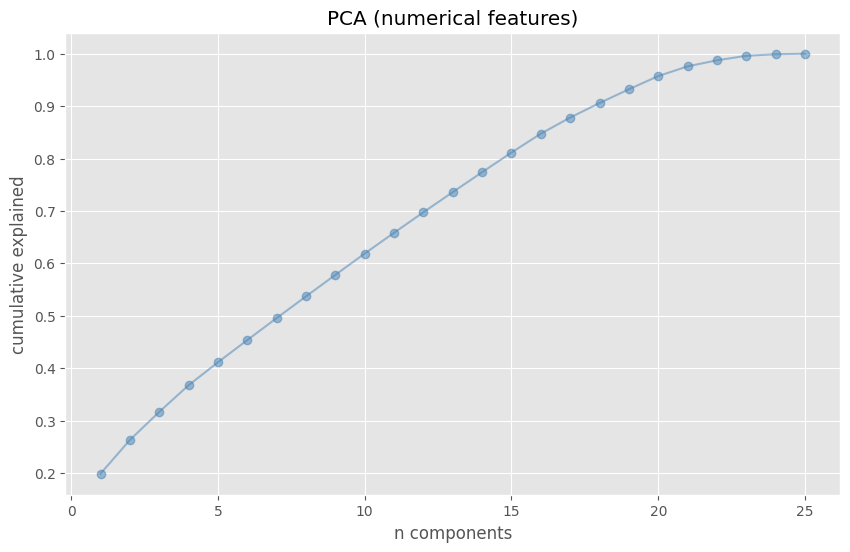

In [9]:
# PCA (numerical features)
pca_num = PCA(random_state=42).fit(num_pipeline.fit_transform(X_train[num_cols]))
expl_num = pca_num.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(expl_num)+1), expl_num.cumsum(), color="steelblue", alpha=0.5, marker="o")
plt.title("PCA (numerical features)")
plt.xlabel("n components")
plt.ylabel("cumulative explained")
plt.grid(True)
plt.show()

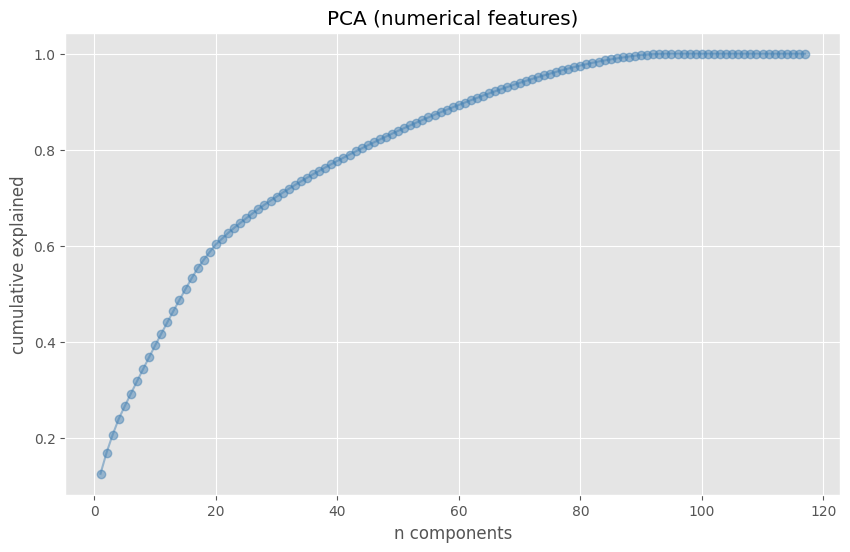

In [10]:
# PCA (preprocessed data)
pca_full = PCA(random_state=42).fit(X_train_prep)
expl_full = pca_full.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(expl_full)+1), expl_full.cumsum(), color="steelblue", alpha=0.5, marker="o")
plt.title("PCA (numerical features)")
plt.xlabel("n components")
plt.ylabel("cumulative explained")
plt.grid(True)
plt.show()

## **Feature Selection**

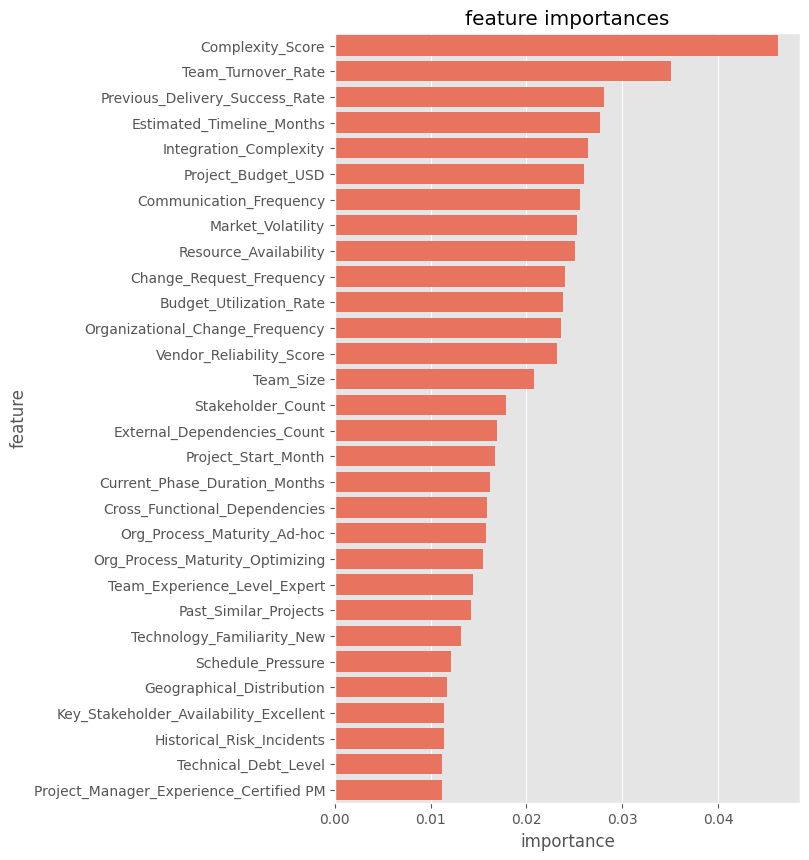

In [11]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf.fit(X_train_prep, y_train)

importances = pd.Series(rf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(6, 10))
sns.barplot(x=importances.head(30).values, y=importances.head(30).index, color="tomato")
plt.title("feature importances")
plt.xlabel("importance")
plt.ylabel("feature")
plt.show()

In [12]:
N = 30

selected_features = importances.head(N).index.tolist()
selected_idx = [feature_names.index(f) for f in selected_features]

X_train_sel = X_train_prep[:, selected_idx]
X_test_sel = X_test_prep[:, selected_idx]

## **Save Data**

In [13]:
# dataset - processed
df_train_prep = pd.DataFrame(X_train_prep, columns=feature_names)
df_train_prep["Risk_Level"] = y_train.reset_index(drop=True)

df_test_prep = pd.DataFrame(X_test_prep, columns=feature_names)
df_test_prep["Risk_Level"] = y_test.reset_index(drop=True)

df_train_prep.to_csv("prep_train.csv", index=False)
df_test_prep.to_csv("prep_test.csv", index=False)

# dataset - features selection
df_train_sel = pd.DataFrame(X_train_sel, columns=selected_features)
df_train_sel["Risk_Level"] = y_train.reset_index(drop=True)

df_test_sel = pd.DataFrame(X_test_sel, columns=selected_features)
df_test_sel["Risk_Level"] = y_test.reset_index(drop=True)

df_train_sel.to_csv("sel_train.csv", index=False)
df_test_sel.to_csv("sel_test.csv", index=False)